In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder, 
    OrdinalEncoder, 
    PowerTransformer, 
    StandardScaler
)

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_CATEGORIZADOS, DADOS_TRATADOS
from src.graficos import plot_coeficientes, plot_residuos

sns.set_theme(palette="bright")

RANDOM_STATE = 42

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59,2,32.099998,101.0,157,93.199997,38.0,4.0,4.8598,87,151
1,48,1,21.600000,87.0,183,103.199997,70.0,3.0,3.8918,69,75
2,72,2,30.500000,93.0,156,93.599998,41.0,4.0,4.6728,85,141
3,24,1,25.299999,84.0,198,131.399994,40.0,5.0,4.8903,89,206
4,50,1,23.000000,101.0,192,125.400002,52.0,4.0,4.2905,80,135


In [3]:
df["sexo"] = df["sexo"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   idade             442 non-null    int8    
 1   sexo              442 non-null    category
 2   imc               442 non-null    float32 
 3   pressao_media     442 non-null    float32 
 4   colesterol_total  442 non-null    int16   
 5   ldl               442 non-null    float32 
 6   hdl               442 non-null    float32 
 7   colesterol_hdl    442 non-null    float32 
 8   triglicerides     442 non-null    float32 
 9   glicose           442 non-null    int8    
 10  target            442 non-null    int16   
dtypes: category(1), float32(6), int16(2), int8(2)
memory usage: 13.6 KB


In [4]:
#Tem algumas colunas que possuem uma simetreia para fazer um power transform

In [5]:
"""Colunas para PowerTransformer (simetria a acima de 0.3 e tenha outliers)

-imc
-ldl
-hdl
-colesterol_total


Colunas para inteiro
- colesterol_hdl

Colunas para StandardScaler
-todas as demais

"""

'Colunas para PowerTransformer (simetria a acima de 0.3 e tenha outliers)\n\n-imc\n-ldl\n-hdl\n-colesterol_total\n\n\nColunas para inteiro\n- colesterol_hdl\n\nColunas para StandardScaler\n-todas as demais\n\n'

In [6]:
df["colesterol_hdl"] = df["colesterol_hdl"].round().astype("int") 

df["colesterol_hdl"].value_counts()

colesterol_hdl
3    141
4    126
5     84
6     41
2     30
7     14
8      5
9      1
Name: count, dtype: int64

<Axes: xlabel='colesterol_hdl'>

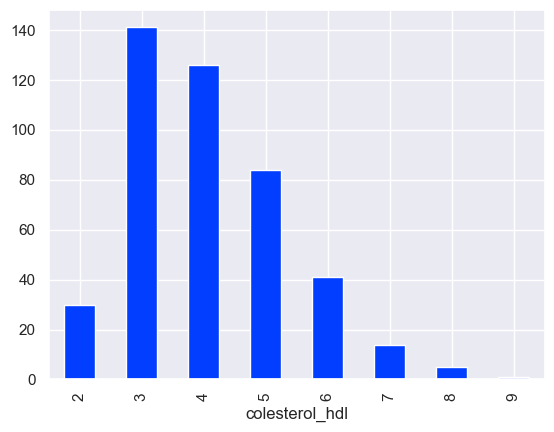

In [7]:
df["colesterol_hdl"].value_counts().sort_index().plot(kind="bar")

In [8]:
#Vamos transformar em uma coluna categorica ordinal(com ordem) Tipo EX: 2(baixo); 3,4,5,(Medio); 7,8,9(Alto)

In [9]:
#cat para indicar que é uma coluna categorica
df["colesterol_hdl_cat"] = pd.cut(
    df["colesterol_hdl"],
    bins=[2,4,6,10], #Esses são os meus cortes
    labels=["2-3", "4-5", "6+"],
    right = False, #Se eu não passo isso ele ignora a direita
)
df["colesterol_hdl_cat"].value_counts().sort_index()


colesterol_hdl_cat
2-3    171
4-5    210
6+      61
Name: count, dtype: int64

In [10]:
df = df.drop(columns = ["colesterol_hdl"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   idade               442 non-null    int8    
 1   sexo                442 non-null    category
 2   imc                 442 non-null    float32 
 3   pressao_media       442 non-null    float32 
 4   colesterol_total    442 non-null    int16   
 5   ldl                 442 non-null    float32 
 6   hdl                 442 non-null    float32 
 7   triglicerides       442 non-null    float32 
 8   glicose             442 non-null    int8    
 9   target              442 non-null    int16   
 10  colesterol_hdl_cat  442 non-null    category
dtypes: category(2), float32(5), int16(2), int8(2)
memory usage: 12.4 KB


In [11]:
df["sexo"] = df["sexo"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   idade               442 non-null    int8    
 1   sexo                442 non-null    category
 2   imc                 442 non-null    float32 
 3   pressao_media       442 non-null    float32 
 4   colesterol_total    442 non-null    int16   
 5   ldl                 442 non-null    float32 
 6   hdl                 442 non-null    float32 
 7   triglicerides       442 non-null    float32 
 8   glicose             442 non-null    int8    
 9   target              442 non-null    int16   
 10  colesterol_hdl_cat  442 non-null    category
dtypes: category(2), float32(5), int16(2), int8(2)
memory usage: 12.4 KB


In [12]:
df.to_parquet(DADOS_CATEGORIZADOS, index=False)

In [13]:
#Criando variáveis úteis

In [15]:
colunas_power_transform = ["imc", "ldl", "hdl", "colesterol_total"]

coluna_target = ["target"]

coluna_ordinal_enconder = ["colesterol_hdl_cat"]

coluna_one_hot_enconder = ["sexo"]

colunas_standard_scaler = [
    coluna
    for coluna in df.columns
    if coluna not in colunas_power_transform + coluna_target + coluna_ordinal_enconder + coluna_one_hot_enconder
]

colunas_standard_scaler

['idade', 'pressao_media', 'triglicerides', 'glicose']

In [ ]:
#OrdinalEncoder
#Por enquanto so vamos se preocupar com o hyperparametro categories

In [ ]:
"""
Parameters:
categories‘auto’ or a list of array-like, default=’auto’
Categories (unique values) per feature:

‘auto’ : Determine categories automatically from the training data.

list : categories[i] holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.

The used categories can be found in the categories_ attribute.

dtypenumber type, default=np.float64
Desired dtype of output.

handle_unknown{‘error’, ‘use_encoded_value’}, default=’error’
When set to ‘error’ an error will be raised in case an unknown categorical feature is present during transform. When set to ‘use_encoded_value’, the encoded value of unknown categories will be set to the value given for the parameter unknown_value. In inverse_transform, an unknown category will be denoted as None.

Added in version 0.24.

unknown_valueint or np.nan, default=None
When the parameter handle_unknown is set to ‘use_encoded_value’, this parameter is required and will set the encoded value of unknown categories. It has to be distinct from the values used to encode any of the categories in fit. If set to np.nan, the dtype parameter must be a float dtype.

Added in version 0.24.

encoded_missing_valueint or np.nan, default=np.nan
Encoded value of missing categories. If set to np.nan, then the dtype parameter must be a float dtype.

Added in version 1.1.

min_frequencyint or float, default=None
Specifies the minimum frequency below which a category will be considered infrequent.

If int, categories with a smaller cardinality will be considered infrequent.

If float, categories with a smaller cardinality than min_frequency * n_samples will be considered infrequent.

Added in version 1.3: Read more in the User Guide.

max_categoriesint, default=None
Specifies an upper limit to the number of output categories for each input feature when considering infrequent categories. If there are infrequent categories, max_categories includes the category representing the infrequent categories along with the frequent categories. If None, there is no limit to the number of output features.

max_categories do not take into account missing or unknown categories. Setting unknown_value or encoded_missing_value to an integer will increase the number of unique integer codes by one each. This can result in up to max_categories + 2 integer codes.

"""

In [16]:
categorias_ordinal_encoder = [
    ["2-3", "4-5", "6+"],
]

In [ ]:
#Pipeline

In [19]:
X = df.drop(columns = "target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = RANDOM_STATE
)

In [ ]:
"""
PowerTransformer
class sklearn.preprocessing.PowerTransformer(method='yeo-johnson', *, standardize=True, copy=True)[source]
Apply a power transform featurewise to make data more Gaussian-like.

Power transforms are a family of parametric, monotonic transformations that are applied to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

Currently, PowerTransformer supports the Box-Cox transform and the Yeo-Johnson transform. The optimal parameter for stabilizing variance and minimizing skewness is estimated through maximum likelihood.

Box-Cox requires input data to be strictly positive, while Yeo-Johnson supports both positive or negative data.

By default, zero-mean, unit-variance normalization is applied to the transformed data.

For an example visualization, refer to Compare PowerTransformer with other scalers. To see the effect of Box-Cox and Yeo-Johnson transformations on different distributions, see: Map data to a normal distribution.

Read more in the User Guide.

Added in version 0.20.

Parameters:
method
{‘yeo-johnson’, ‘box-cox’}, default=’yeo-johnson’
The power transform method. Available methods are:

‘yeo-johnson’ [1], works with positive and negative values

‘box-cox’ [2], only works with strictly positive values

standardize
bool, default=True
Set to True to apply zero-mean, unit-variance normalization to the transformed output.

copy
bool, default=True
Set to False to perform inplace computation during transformation.

"""

In [23]:
preprocessamento =  ColumnTransformer(
    [
        ("power_transform", PowerTransformer(method = "box-cox"), colunas_power_transform),
        ("standard_scaler", StandardScaler(), colunas_standard_scaler),
        ("ordinal_encorder", OrdinalEncoder(categories = categorias_ordinal_encoder), coluna_ordinal_enconder),
        ("one_hot_encoder", OneHotEncoder(drop = "if_binary"), coluna_one_hot_enconder),
    ]
)

In [26]:
pipeline = Pipeline([
    ("preprocessor", preprocessamento),
    ("reg", LinearRegression())
])

pipeline

,steps,"[('preprocessor', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('power_transform', ...), ('standard_scaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('power_transform', ...), ('standard_scaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
pipeline.named_steps

{'preprocessor': ColumnTransformer(transformers=[('power_transform',
                                  PowerTransformer(method='box-cox'),
                                  ['imc', 'ldl', 'hdl', 'colesterol_total']),
                                 ('standard_scaler', StandardScaler(),
                                  ['idade', 'pressao_media', 'triglicerides',
                                   'glicose']),
                                 ('ordinal_encorder',
                                  OrdinalEncoder(categories=[['2-3', '4-5',
                                                              '6+']]),
                                  ['colesterol_hdl_cat']),
                                 ('one_hot_encoder',
                                  OneHotEncoder(drop='if_binary'), ['sexo'])]),
 'reg': LinearRegression()}

In [47]:
pipeline["reg"].coef_

array([ 24.60290159,  16.78307617,  -0.13708291, -33.23832884,
         0.90944598,  16.86897392,  31.42600821,   3.2021447 ,
        13.19326265, -24.68911844])

In [48]:
pipeline["reg"].intercept_

np.float64(155.40505912942442)

In [49]:
pipeline["preprocessor"].feature_names_in_ #Isso foi o que entrou no preprocessamento

array(['idade', 'sexo', 'imc', 'pressao_media', 'colesterol_total', 'ldl',
       'hdl', 'triglicerides', 'glicose', 'colesterol_hdl_cat'],
      dtype=object)

In [50]:
pipeline["preprocessor"].get_feature_names_out() #Isso foi o que saiu

array(['power_transform__imc', 'power_transform__ldl',
       'power_transform__hdl', 'power_transform__colesterol_total',
       'standard_scaler__idade', 'standard_scaler__pressao_media',
       'standard_scaler__triglicerides', 'standard_scaler__glicose',
       'ordinal_encorder__colesterol_hdl_cat', 'one_hot_encoder__sexo_2'],
      dtype=object)

In [51]:
coefs = dataframe_coeficientes(
    pipeline["reg"].coef_,
    pipeline["preprocessor"].get_feature_names_out()
)

coefs

,coeficiente
power_transform__colesterol_total,-33.238329
one_hot_encoder__sexo_2,-24.689118
power_transform__hdl,-0.137083
standard_scaler__idade,0.909446
standard_scaler__glicose,3.202145
ordinal_encorder__colesterol_hdl_cat,13.193263
power_transform__ldl,16.783076
standard_scaler__pressao_media,16.868974
power_transform__imc,24.602902
standard_scaler__triglicerides,31.426008


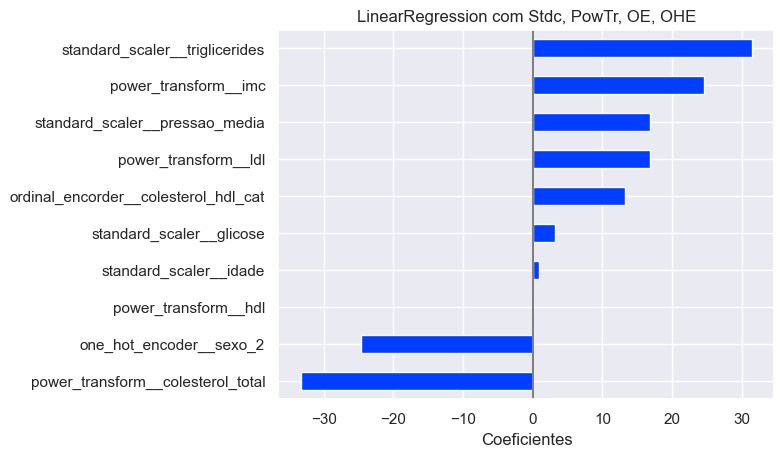

In [52]:
plot_coeficientes(coefs, "LinearRegression com Stdc, PowTr, OE, OHE")

In [53]:
#Visualizando transformações

In [54]:
pipeline["preprocessor"].transform(X)[:5]

array([[ 1.24028134, -0.68239766, -0.92678279, -0.9118979 ,  0.7917738 ,
         0.42754114,  0.39135751, -0.40439731,  1.        ,  1.        ],
       [-1.21030366, -0.32397613,  1.49296749, -0.09894422, -0.0718379 ,
        -0.56832451, -1.45617545, -1.94766474,  0.        ,  0.        ],
       [ 0.94915265, -0.66766673, -0.61978519, -0.94512081,  1.81240582,
        -0.14152497,  0.03444809, -0.57587147,  1.        ,  1.        ],
       [-0.17701314,  0.59447801, -0.71935707,  0.33135122, -1.95608163,
        -0.78172433,  0.44956997, -0.23292314,  1.        ,  0.        ],
       [-0.79063582,  0.40888068,  0.32932299,  0.16226251,  0.08518241,
         0.42754114, -0.69521284, -1.00455689,  1.        ,  0.        ]])

In [55]:
#Ja vimos o que acontece na one hot e agora vamos ver o que acontece com a ordinal

In [61]:
X["colesterol_hdl_cat"].head(5) #o que o ordinal enconder fez nesse caso ele pegou cada categoria e enumerou em 2-3 ele chamou de 0, 4-5 ele chamou de 1 e 6+ ele chamou de 2

0    4-5
1    2-3
2    4-5
3    4-5
4    4-5
Name: colesterol_hdl_cat, dtype: category
Categories (3, object): ['2-3' < '4-5' < '6+']

In [60]:
pipeline["preprocessor"]["ordinal_encorder"].transform(X[["colesterol_hdl_cat"]])[:5]

array([[1.],
       [0.],
       [1.],
       [1.],
       [1.]])

In [ ]:
#Qual foi o efeito do power transform

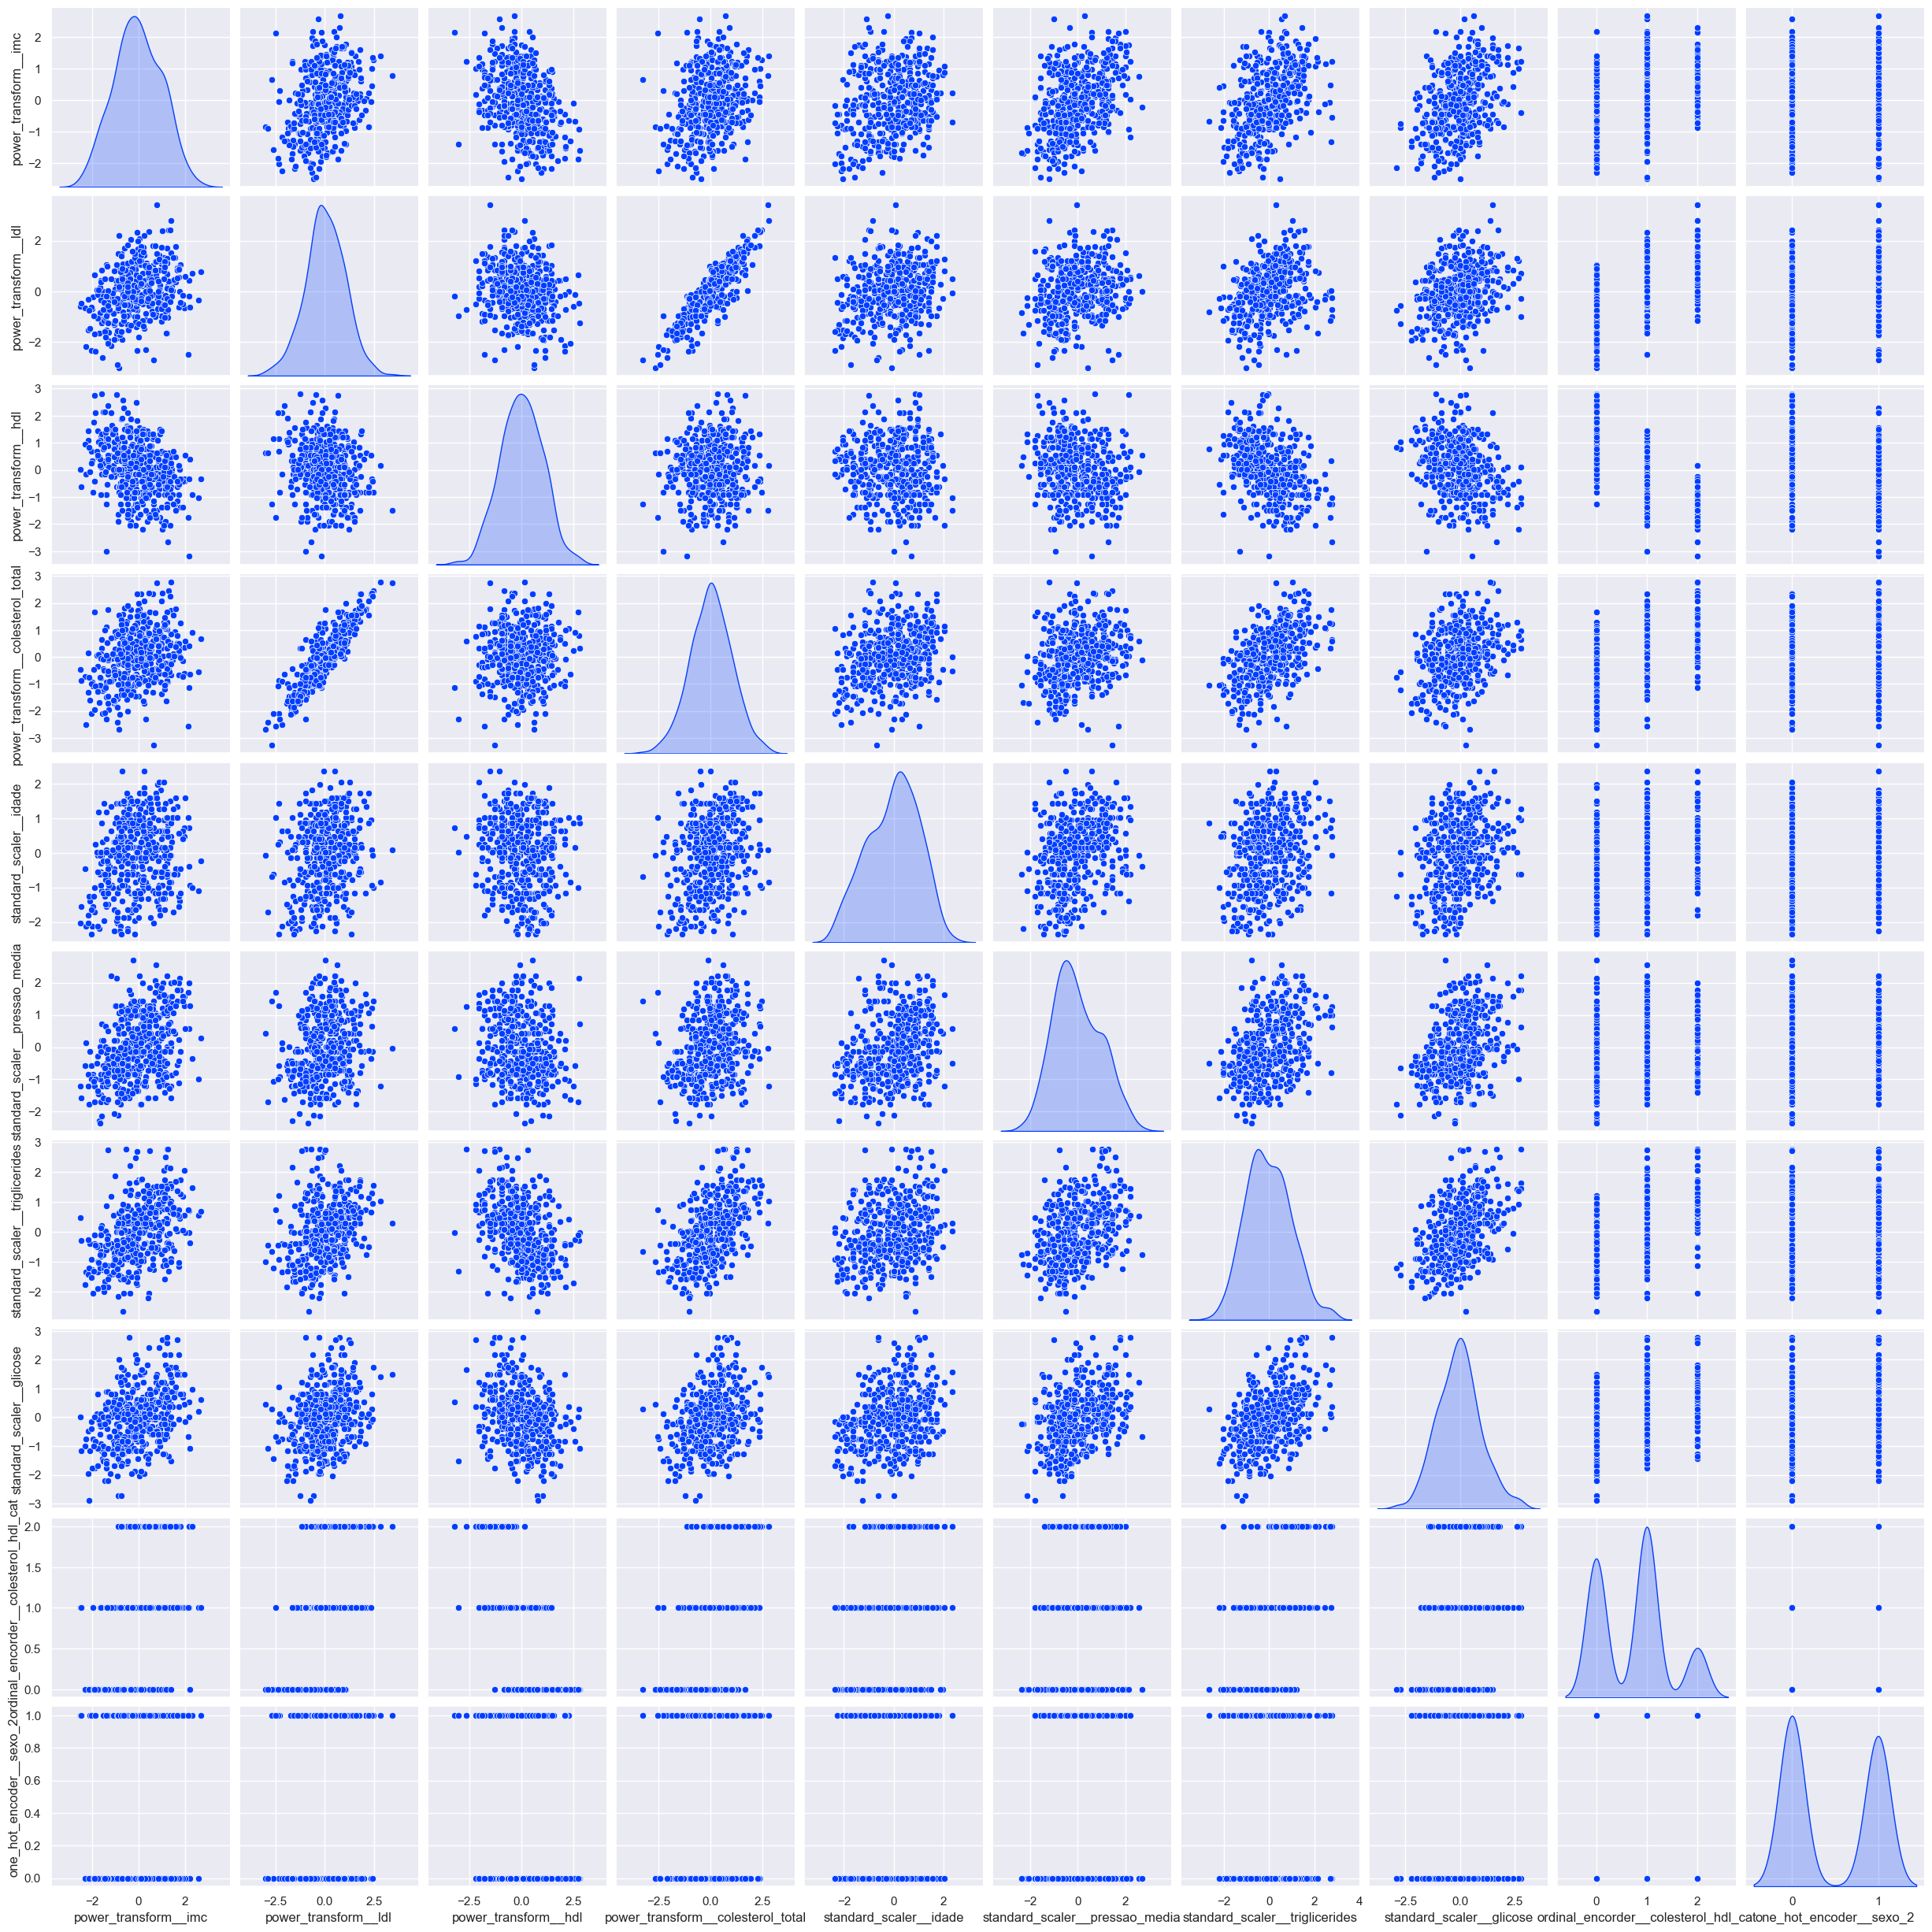

In [64]:
X_scaled = pipeline["preprocessor"].transform(X)

X_scaled = pd.DataFrame(X_scaled, columns = pipeline["preprocessor"].get_feature_names_out())

sns.pairplot(X_scaled, diag_kind = "kde")

In [ ]:
#Avaliando métricas

In [65]:
y_pred = pipeline.predict(X_test)

In [66]:
mean_absolute_error(y_test, y_pred)

43.64265041174001

In [67]:
mean_squared_error(y_test, y_pred)

2957.289307845211

In [68]:
root_mean_squared_error(y_test, y_pred)

54.380964572589285

In [69]:
r2_score(y_test, y_pred)

0.44182623522000763

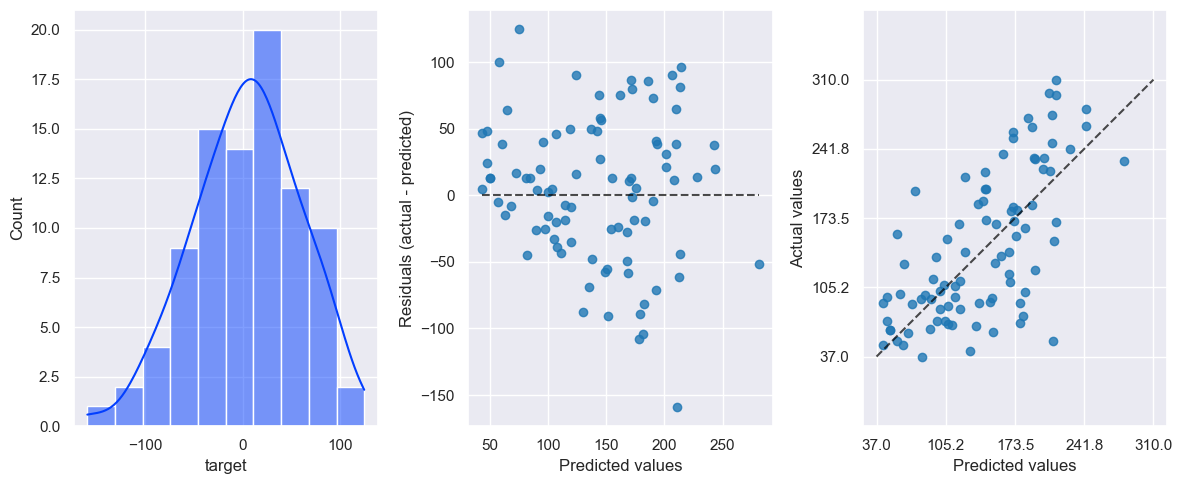

In [70]:
plot_residuos(y_test, y_pred)

In [ ]:
#Introduzindo a ideia de modificar o target